# MASTER THESIS - model V4 summer V4

It includes g simulation

This notebook demonstrates the usage of the `DarkGreyBox` models via fitting them with `DarkGreyFit`

Model V3 --> this model is using the TiTmCn3R2C grey-box model on a summer period (1st of September to 15th of September) where there is no heating at all

## Importation

In [1]:
import sys
import importlib
from pathlib import Path
import pvlib
from scipy.interpolate import BSpline

# go from ...\docs\tutorials up two levels to the repo root (...\darkgreybox)
repo_root = Path.cwd().parents[1]
sys.path.insert(0, str(repo_root))
importlib.invalidate_caches()


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, KFold
from statsmodels.graphics.tsaplots import plot_pacf

from darkgreybox.models import TiTmCn2R2C_summer_V9
from darkgreybox.fit import darkgreyfit
from docs.tutorials.util.plot import plot
from docs.tutorials.util.error import rmse

2026-02-23 17:14:33,138 darkgreybox  INFO     Logging enabled...


Our temporal resolution is 5 minutes

In [2]:
# the duration of a record (in h - 5 minutes)
rec_duration = 5/60

## Data Loading and Preprocessing

The data is loaded from the CSV file 'data_summer' and processed to extract relevant variables for the thermal model.

In [3]:
def add_bspline_features(df, n_knots=6, degree=3):
    """Add B-spline basis functions using datetime index."""
    # Extract hour of day from the index (assuming it's datetime)
    hour_of_day = df.index.hour + df.index.minute / 60
    
    # Knots from 6am to 8pm
    knots_interior = np.linspace(6, 20, n_knots)
    knots = np.concatenate([
        [knots_interior[0]] * (degree + 1),
        knots_interior,
        [knots_interior[-1]] * (degree + 1)
    ])
    
    n_basis = len(knots) - degree - 1
    
    for i in range(n_basis):
        coef = np.zeros(n_basis)
        coef[i] = 1.0
        bspline = BSpline(knots, coef, degree)
        df[f'bs_{i}'] = bspline(hour_of_day)
    
    return df, n_basis

In [4]:
input_df = pd.read_csv('./data/data_summer_neighbor.csv', index_col=0, parse_dates=True)

input_df['Ti'] = input_df['R01_06_TRU01']
input_df['qv'] = input_df['R01_06_FCI01']
input_df['c'] = input_df['R01_06_CO201']  # Use processed CO2 column
input_df['Ta'] = input_df['HTR9_VES01_TUD01']
input_df['Ik'] = input_df['HTR9_VES01_SI01']
input_df['Tsup'] = input_df['HTRK_VEN01_SpTI01_C']
input_df['theta_z'] = input_df['HTR9_VES01_AZ01']
input_df['gamma_s'] = input_df['HTR9_VES01_SV01']
input_df['T_neigh_1'] = input_df['R01_02_TRU01']
input_df['T_neigh_2'] = input_df['R01_07_TRU01']


# Set initial conditions
input_df['Ti0'] = input_df['Ti'].iloc[0]
input_df['Tm0'] = input_df['Ti'].iloc[0]
input_df['c0'] = input_df['c'].iloc[0]
input_df['N0'] = 0 #We suppose no one in the room at the beginning


input_X = input_df[['qv', 'c', 'Ta', 'Ik', 'Tsup', 'theta_z', 'gamma_s', 'Ti0', 'Tm0', 'c0', 'N0', 'T_neigh_1', 'T_neigh_2']]
input_y = input_df['Ti']


print(f'Input X shape: {input_X.shape}, input y shape: {input_y.shape}')

Input X shape: (4296, 13), input y shape: (4296,)


## Data Splitting

Initial conditions are set for the state variables at t=0, using the first measurements from the dataset. The data is then split into training (80%) and test (20%) sets for model validation.
`shuffle=False` to preserve the temporal order of the time series data. This is important for thermal modeling where historical context matters.

In [5]:
X_train, X_test, y_train, y_test = train_test_split(input_X, input_y, test_size=0.2, shuffle=False)

print(f'Train: X shape: {X_train.shape}, y shape: {y_train.shape}')
print(f'Test: X shape: {X_test.shape}, y shape: {y_test.shape}')

# Before training:
X_train, n_bsplines = add_bspline_features(X_train)
X_test, _ = add_bspline_features(X_test)
print(f"Created {n_bsplines} B-spline basis functions")

Train: X shape: (3436, 13), y shape: (3436,)
Test: X shape: (860, 13), y shape: (860,)
Created 10 B-spline basis functions


## Model Training Parameters and Physical Constants

The parameter ranges are carefully chosen to reflect realistic physical bounds and to ensure the optimizer does not hit artificial limits during fitting. Capacitances and resistances are estimated from building material properties and geometry, while internal gains and constants are set according to typical values found in literature or building standards. This approach balances physical realism with flexibility for model calibration.

In [6]:
S_room = 11                             #Surface of the room, found on Revit (m²)
A_windows = 5.48                        #Window area found on Revit (m²)
H_room = 2.7                            #Height of the room (m)
V_room = S_room * H_room                #Volume of the room (m³)
orientation = 270                       # West orientation in degrees

A_neigh_1 = 4*H_room                    # Surface of the neighbor wall 1 (m²) - estimated based on Revit
A_neigh_2 = 4*H_room                    # Surface of the neighbor wall 2 (m²) - estimated based on Revit
U_interior_wall = 1.8                   # U-value of interior walls (W/m²K) - single gypsum board + metal stud 

Rneih_1_i = 1/(U_interior_wall*A_neigh_1)
Rneih_2_i = 1/(U_interior_wall*A_neigh_2)


# Capacitances initial guesses
# C=ρ×V×c_p [J/K] (ρ density kg/m³, V volume m³, c_p specific heat capacity J/kgK)
rho_air_init = 1.2          # kg/m³
cp_air_init = 1005          # J/kgK
rho_furn_init = 500         # kg/m³
cp_furn_init = 1200         # J/kgK
V_furn_init = 0.1 * V_room  # m³  (10% of room volume as furniture/contents volume)
Ci_i = rho_air_init * V_room * cp_air_init + rho_furn_init * V_furn_init * cp_furn_init

rho_wall = 2200             # kg/m³
cp_conc  = 840              # J/kgK
wall_thickness = 0.1        # m
Cm_i = rho_wall * (S_room * wall_thickness) * cp_conc  



# Resistances initial guesses
# R=1/(U*A) or 1/(h*A) [K/W]
h_conv = 8                     # W/m²K
S_int_mass = 0.6 * S_room      # internal surfaces area ~60%
Rim_i = 1 / (h_conv * S_int_mass)

U_env = 0.25                   # W/m²K
Rout_i= 1 / (U_env * S_room)


# Capacitances and resistances variation ranges
# WIDENED based on optimizer hitting bounds (see diagnostic cell)
Ci_min = 0.05*Ci_i      # Was 0.2x → lowered (optimizer wanted smaller)
Ci_max = 2*Ci_i         # Keep similar
Cm_min = 0.1*Cm_i       # Was 0.5x → lowered (optimizer wanted smaller)
Cm_max = 3*Cm_i         # Keep similar

Rim_min = 0.2*Rim_i     # Slightly lower
Rim_max = 2*Rim_i       # Keep similar
Rout_min = 0.1*Rout_i   # Was 0.5x → lowered (optimizer wanted more heat loss)
Rout_max = 2*Rout_i     # Keep similar



# Define training parameters
train_params_TiTmCn2R2C_summer_V4 = {
    'Ti0': {'value': input_df.iloc[0]['Ti0'], 'vary': False},               # Initial indoor temperature
    'Tm0': {'value': input_df.iloc[0]['Tm0'], 'vary': False},               # Initial thermal mass temperature
    'c0': {'value': input_df.iloc[0]['c0'], 'vary': False},                 # Initial CO2 concentration
    'N0': {'value': input_df.iloc[0]['N0'], 'vary': False},                 # Initial number of occupants
    
    #'Ci': {'value': Ci_i, 'vary': True, 'min': Ci_min, 'max': Ci_max},      # Air + light internal components heat capacity at air node (fast mass at Ti)
    #'Cm': {'value': Cm_i, 'vary': True, 'min': Cm_min, 'max': Cm_max},      # Thermal mass heat capacity (heavy structural mass at Tm)
    #'Rim': {'value': Rim_i, 'vary': True, 'min': Rim_min, 'max': Rim_max},  # Thermal resistance indoor air ↔ thermal mass (heat air ↔ building structure)
    #'Rout': {'value': Rout_i, 'vary': True, 'min': Rout_min, 'max': Rout_max},  # Overall thermal resistance indoor air ↔ ambient/outdoor air (heat loss path)
    'Ci': {'value': 5000, 'vary': True, 'min': 1000, 'max': 50000},
    'Cm': {'value': 100000, 'vary': True, 'min': 1000, 'max': 1000000},    # Bigger mass\n",
    'Rim': {'value': 0.005, 'vary': True, 'min': 0.001, 'max': 0.01},           # Mass-air  \n",
    'Rout': {'value': 0.15, 'vary': True, 'min': 0.01, 'max': 2.0},         # Envelope\n",
    'q_pers': {'value': 75, 'vary': False},                                 # Internal gains per person
    'q_equip_var': {'value': 80, 'vary': False},                            # Variable equipment gains per person
    'q_equip_const': {'value': 10, 'vary': False},                          # Constant equipment gains
    'V': {'value': S_room*H_room, 'vary': False},                           # Volume of the room
    'S': {'value': S_room, 'vary': False},                                  # Surface of the room
    'A': {'value': A_windows, 'vary': False},                               # Window area
    'G': {'value': 0.016, 'vary': False},                                   # Global radiation factor
    'c_out': {'value': 400, 'vary': False},                                 # Outdoor CO2 concentration
    'rho_air': {'value': 1.2, 'vary': False},                               # Air density
    'cp_air': {'value': 1000, 'vary': False},                               # Specific heat capacity of air
    #'g': {'value': 0.55, 'vary': False},                                    # total solar energy transmittance of the glazing 
    'alpha': {'value': 0.1, 'vary': True, 'min': 0.01, 'max': 0.5},         # CO2 occupancy filter parameter
    'gamma_g': {'value': orientation, 'vary': False},                    # glazing angle for IAM calculation
    'n': {'value': 1.526, 'vary': False},                                        # refractive index for IAM calculation
    'K': {'value': 4, 'vary': False},                                   # absorption coefficient for IAM calculation (1/m)
    'L': {'value': 0.003, 'vary': False},                                     # glazing thickness for IAM calculation (m)
    'Rneigh_1': {'value': Rneih_1_i, 'vary': True, 'min': Rneih_1_i*0.1, 'max': Rneih_1_i*10},         # Thermal resistance between the room and the neighboring spaces (simplified representation of heat transfer through internal walls)
    'Rneigh_2': {'value': Rneih_2_i, 'vary': True, 'min': Rneih_2_i*0.1, 'max': Rneih_2_i*10},         # Thermal resistance between the room and the neighboring spaces (simplified representation of heat transfer through internal walls)
    'f_sol': {'value': 0.4, 'vary': True, 'min': 0, 'max': 1},         # Solar gains distribution factor (fraction of solar gains directly affecting indoor air node)
    # 10 B-spline coefficients
    'phi_a': {'value': 0.7, 'vary': True, 'min': 0, 'max': 1},
    'phi_b': {'value': 0.7, 'vary': True, 'min': 0, 'max': 1},
    'phi_c': {'value': 0.7, 'vary': True, 'min': 0, 'max': 1},
    'phi_d': {'value': 0.7, 'vary': True, 'min': 0, 'max': 1},
    'phi_e': {'value': 0.7, 'vary': True, 'min': 0, 'max': 1},
    'phi_f': {'value': 0.7, 'vary': True, 'min': 0, 'max': 1},
    'phi_g': {'value': 0.7, 'vary': True, 'min': 0, 'max': 1},  
    'phi_h': {'value': 0.7, 'vary': True, 'min': 0, 'max': 1},
    'phi_i': {'value': 0.7, 'vary': True, 'min': 0, 'max': 1},
    'phi_j': {'value': 0.7, 'vary': True, 'min': 0, 'max': 1},
}

# Verify stability
print(f"dt = {rec_duration:.4f} hours ({rec_duration * 60:.2f} minutes)")

dt = 0.0833 hours (5.00 minutes)


### 1: Initial conditions
Set up our initial conditions parameters map for testing

### 2: Error metric
To evaluate the performance of our models we will need to define an error metric. Again, there is a wide range of options available from `sklearn`

### 3: Fit method
Under the hood, `DarkGreyBox` uses `lmfit.minimize` to fit the thermal model parameters to the training data by passing it a custom objective function defined by the model class. The fit method used by `lmfit.minimize` can be customised as well. The standard Nelder-Mead and Levenberg-Marquardt methods work well in general. Here we use the Nelder-Mead method.

### 4: Choice of the model

In [7]:
ic_params_map = {
    'Ti0': lambda _X_test, y_test, _train_result: y_test.iloc[0],
    'Tm0': lambda X_test, _y_test, train_result: train_result.var['Tm'][-1] if 'Tm' in train_result.var else X_test.iloc[0]['Tm0'],
    'c0': lambda X_test, _y_test, train_result: train_result.var['c'][-1] if 'c' in train_result.var else X_test.iloc[0]['c0'],
    'N0': lambda X_test, _y_test, train_result: train_result.var['N'][-1] if 'N' in train_result.var else X_test.iloc[0]['N0'],
}

error_metric = rmse

method = 'nelder'

models = [TiTmCn2R2C_summer_V9(train_params_TiTmCn2R2C_summer_V4, rec_duration)]

Now, it is time to run the simulation:

In [8]:
# Run the darkgreyfit
df = darkgreyfit(
    models=models,
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    ic_params_map=ic_params_map,
    error_metric=error_metric,
    prefit_filter=None,
    prefit_splits=None,
    method=method,
    n_jobs=1
)

print("Fitting complete!")
print(f"DataFrame shape: {df.shape}")

df

model = df.iloc[0][('train', 'model')]
train_results = df.iloc[0][('train', 'model_result')]
test_results = df.iloc[0][('test', 'model_result')]

# Display model parameters safely
if hasattr(model, "result") and hasattr(model.result, "params"):
    display(model.result.params)
else:
    print("Model parameters not available.")

# Print initial, real initial guess (used in fit), and estimated R and C values
# Initial parameter guesses (from physical calculations)
try:
    init_params = {
        'Ci': {'value': Ci_i},
        'Cm': {'value': Cm_i},
        'Rim': {'value': Rim_i},
        'Rout': {'value': Rout_i}
    }
except NameError:
    # If any of the variables are not defined, set to None
    init_params = {
        'Ci': {'value': None},
        'Cm': {'value': None},
        'Rim': {'value': None},
        'Rout': {'value': None}
    }

# Real initial guess used in fit (from train_params_TiTmCn2R2C_summer)
real_init_params = {}
for key in ['Ci', 'Cm', 'Rim', 'Rout']:
    try:
        real_init_params[key] = train_params_TiTmCn2R2C_summer_V2[key]['value']
    except Exception:
        real_init_params[key] = None

if hasattr(model, "result") and hasattr(model.result, "params"):
    est_params = model.result.params
    print("Parameter   | Initial Guess (calc) | Real Initial Guess (used) | Estimated Value")
    print("--------------------------------------------------------------------------")
    for key in ['Ci', 'Cm', 'Rim', 'Rout']:
        init_val = init_params[key]['value']
        real_init_val = real_init_params[key]
        est_val = est_params[key].value if key in est_params else None
        if init_val is not None and real_init_val is not None and est_val is not None:
            print(f"{key:10} | {init_val:18.4f} | {real_init_val:23.4f} | {est_val:15.4f}")
        elif init_val is not None and real_init_val is not None:
            print(f"{key:10} | {init_val:18.4f} | {real_init_val:23.4f} | {'N/A':>15}")
        elif real_init_val is not None and est_val is not None:
            print(f"{key:10} | {'N/A':>18} | {real_init_val:23.4f} | {est_val:15.4f}")
        elif init_val is not None and est_val is not None:
            print(f"{key:10} | {init_val:18.4f} | {'N/A':>23} | {est_val:15.4f}")
        else:
            print(f"{key:10} | {'N/A':>18} | {'N/A':>23} | {'N/A':>15}")
else:
    print("Model parameters not available for comparison.")

2026-02-23 17:14:33,527 darkgreybox  INFO     Training models...
2026-02-23 17:28:56,836 darkgreybox  INFO     Generating predictions for 1 models...
Fitting complete!
DataFrame shape: (1, 13)


name,value,initial value,min,max,vary
Ti0,23.8000000,25.36727273,-inf,inf,False
Tm0,24.1705084,25.36727273,-inf,inf,False
c0,431.252581,433.68,-inf,inf,False
N0,5.7274e-31,0.0,-inf,inf,False
Ci,2118.53316,5000.0,1000.00000,50000.0000,True
Cm,9333.53467,100000.0,1000.00000,1000000.00,True
Rim,0.00296015,0.005,1.0000e-03,0.01000000,True
Rout,0.06049947,0.15,0.01000000,2.00000000,True
q_pers,75.0000000,75.0,-inf,inf,False
q_equip_var,80.0000000,80.0,-inf,inf,False


Parameter   | Initial Guess (calc) | Real Initial Guess (used) | Estimated Value
--------------------------------------------------------------------------
Ci         |       1817818.2000 |                     N/A |       2118.5332
Cm         |       2032800.0000 |                     N/A |       9333.5347
Rim        |             0.0189 |                     N/A |          0.0030
Rout       |             0.3636 |                     N/A |          0.0605


## Train results

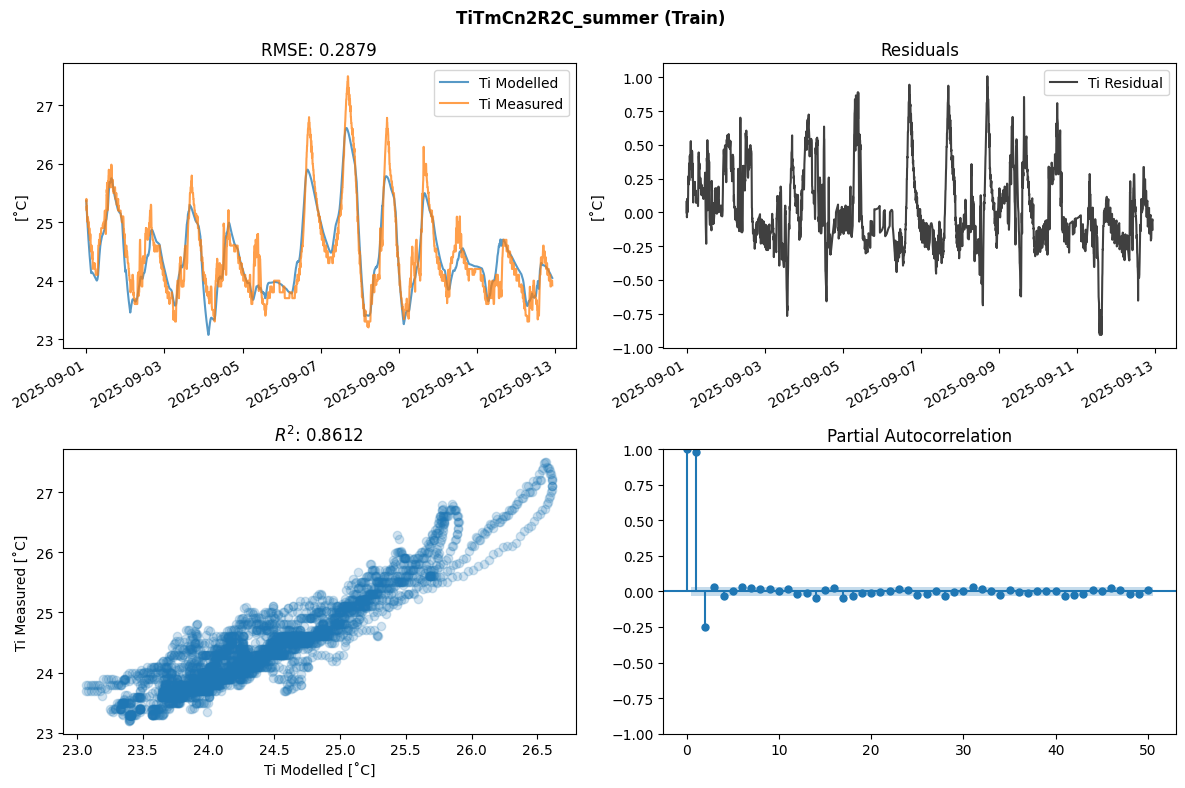

In [9]:
plot(y_train, train_results, 'TiTmCn2R2C_summer (Train)')

## Test results

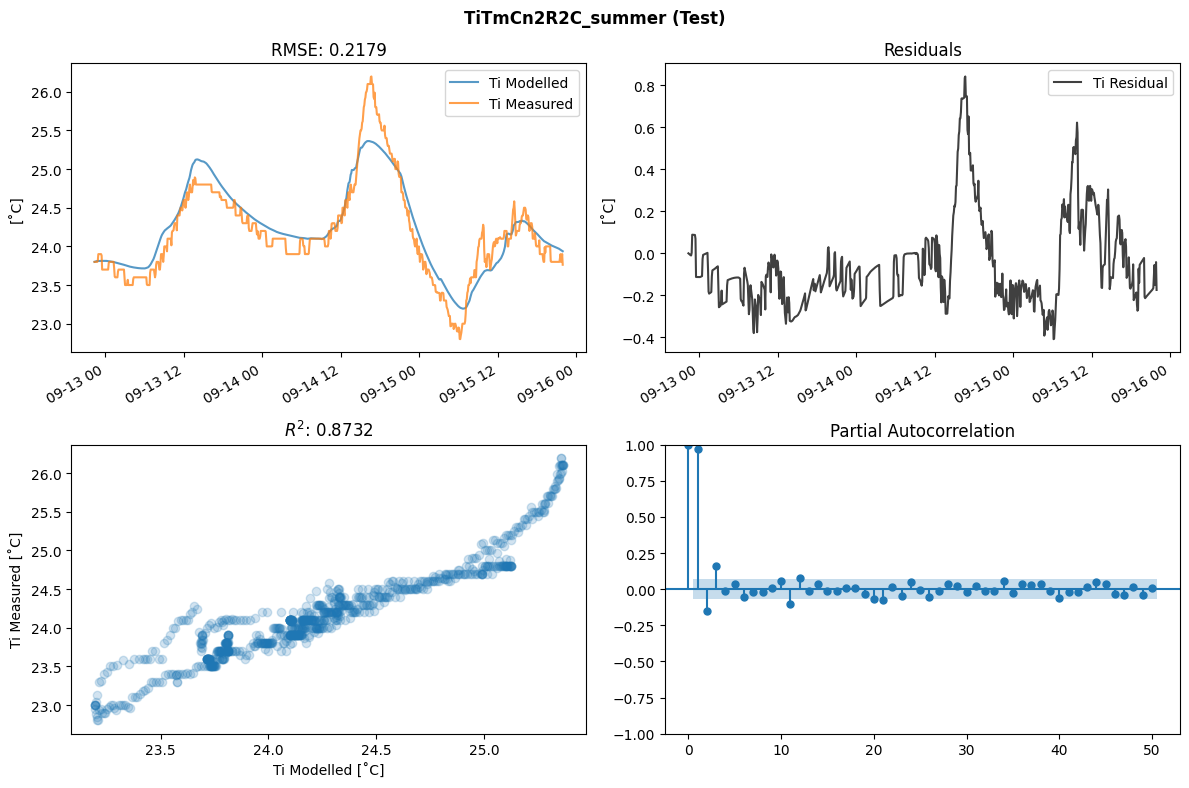

In [10]:
plot(y_test, test_results, 'TiTmCn2R2C_summer (Test)')

In [1]:
# ============================================================
# EXTENDED MODEL VALIDATION — FINAL VERSION (v3)
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from scipy import signal, stats
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
import warnings
warnings.filterwarnings('ignore')

# ----------------------------------------------------------
# 1. EXTRACT RESIDUALS — TWO TYPES
# ----------------------------------------------------------
Ti_measured  = y_test.values
Ti_modelled  = test_results.var['Ti']

# FREE-RUN → RMSE, R², MAE, scatter, time series
residuals    = Ti_measured - Ti_modelled
n            = len(residuals)

# ONE-STEP-AHEAD → ACF, PACF, Periodogram, Ljung-Box
residuals_1s = np.diff(residuals)
n1           = len(residuals_1s)

# ----------------------------------------------------------
# 2. COMPUTE ALL METRICS
# ----------------------------------------------------------

# Goodness of fit (free-run)
rmse_val  = np.sqrt(np.mean(residuals**2))
mae_val   = np.mean(np.abs(residuals))
ss_res    = np.sum(residuals**2)
ss_tot    = np.sum((Ti_measured - np.mean(Ti_measured))**2)
r2_val    = 1 - (ss_res / ss_tot)
nrmse_val = rmse_val / (Ti_measured.max() - Ti_measured.min())

# Likelihood-based metrics (free-run)
sigma2  = np.var(residuals, ddof=1)
log_lik = -0.5 * n * np.log(2 * np.pi * sigma2) - 0.5 * np.sum(residuals**2) / sigma2
if 'model' in locals() and hasattr(model, 'result') and hasattr(model.result, 'params'):
    k_params = sum(1 for p in model.result.params.values() if getattr(p, 'vary', False))
else:
    k_params = sum(1 for p in train_params_TiTmCn2R2C_summer_V4.values()
                   if isinstance(p, dict) and p.get('vary', False))
aic_val = -2 * log_lik + 2 * k_params
bic_val = -2 * log_lik + k_params * np.log(n)

# Free-run residual statistics
res_mean = np.mean(residuals)
res_std  = np.std(residuals, ddof=1)
res_skew = stats.skew(residuals)
res_kurt = stats.kurtosis(residuals)

# One-step residual statistics
res1_mean = np.mean(residuals_1s)
res1_std  = np.std(residuals_1s, ddof=1)
res1_skew = stats.skew(residuals_1s)
res1_kurt = stats.kurtosis(residuals_1s)

# Normality tests (one-step)
shapiro_stat, shapiro_p = stats.shapiro(residuals_1s[:min(5000, n1)])
jb_stat, jb_p           = stats.jarque_bera(residuals_1s)

# Ljung-Box (one-step)
lb_results = acorr_ljungbox(residuals_1s, lags=[1, 6, 12, 24, 48], return_df=True)

# ----------------------------------------------------------
# 3. PRINT VALIDATION REPORT  (scientific notation for p)
# ----------------------------------------------------------
def fmt_p(p):
    """Format p-value: show more precision, switch to sci notation if tiny."""
    if p < 0.0001:
        return f"{p:.3e}"
    return f"{p:.6f}"

print("=" * 65)
print("         EXTENDED MODEL VALIDATION REPORT (TEST)")
print("=" * 65)

print("\n── GOODNESS OF FIT (free-run simulation) ───────────────────")
print(f"  RMSE:              {rmse_val:.4f} °C")
print(f"  MAE:               {mae_val:.4f} °C")
print(f"  NRMSE (by range):  {nrmse_val:.4f}")
print(f"  R²:                {r2_val:.4f}")

print("\n── LIKELIHOOD-BASED CRITERIA ───────────────────────────────")
print(f"  Log-Likelihood:     {log_lik:.4f}")
print(f"  AIC (lower=better): {aic_val:.4f}")
print(f"  BIC (lower=better): {bic_val:.4f}")
print(f"  Parameters varied:  {k_params}")

print("\n── RESIDUAL STATISTICS (free-run) ──────────────────────────")
print(f"  Mean:     {res_mean:.6f} °C  (ideal ≈ 0)")
print(f"  Std Dev:  {res_std:.6f} °C")
print(f"  Skewness: {res_skew:.6f}    (ideal ≈ 0)")
print(f"  Kurtosis: {res_kurt:.6f}    (ideal ≈ 0)")

print("\n── RESIDUAL STATISTICS (one-step-ahead) ────────────────────")
print(f"  Mean:     {res1_mean:.6f} °C  (ideal ≈ 0)")
print(f"  Std Dev:  {res1_std:.6f} °C")
print(f"  Skewness: {res1_skew:.6f}    (ideal ≈ 0)")
print(f"  Kurtosis: {res1_kurt:.6f}    (ideal ≈ 0)")

print("\n── NORMALITY TESTS — one-step (H0: Gaussian) ──────────────")
print(f"  Shapiro-Wilk:  W={shapiro_stat:.6f},  p={fmt_p(shapiro_p)}  "
      f"{'✓ Normal' if shapiro_p > 0.05 else '✗ Not Normal'}")
print(f"  Jarque-Bera:   JB={jb_stat:.4f},  p={fmt_p(jb_p)}  "
      f"{'✓ Normal' if jb_p > 0.05 else '✗ Not Normal'}")

print("\n── LJUNG-BOX — one-step (H0: white noise) ─────────────────")
print(f"  {'Lag':<6} {'Q-stat':>10} {'p-value':>14}  Result")
print(f"  {'-'*46}")
for lag in [1, 6, 12, 24, 48]:
    row    = lb_results.loc[lag]
    result = '✓ White noise' if row['lb_pvalue'] > 0.05 else '✗ Autocorrelation'
    print(f"  {lag:<6} {row['lb_stat']:>10.4f} {fmt_p(row['lb_pvalue']):>14}  {result}")
print("=" * 65)

# ----------------------------------------------------------
# 4. DIAGNOSTIC PLOTS
# ----------------------------------------------------------
fig, axes = plt.subplots(3, 3, figsize=(18, 12))
fig.suptitle(
    f'Extended Validation — TiTmCn2R2C_summer (Test)\n'
    f'RMSE={rmse_val:.4f} °C  |  R²={r2_val:.4f}  |  AIC={aic_val:.1f}  |  BIC={bic_val:.1f}',
    fontsize=13, fontweight='bold'
)

time_idx    = y_test.index
time_idx_1s = y_test.index[1:]

# ── Plot 1: Time series ──────────────────────────────────
ax = axes[0, 0]
ax.plot(time_idx, Ti_measured, label='Ti Measured', color='orange',    lw=1.5, alpha=0.85)
ax.plot(time_idx, Ti_modelled, label='Ti Modelled', color='steelblue', lw=1.5)
ax.set_ylabel('°C')
ax.set_title('Measured vs Modelled')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

# ── Plot 2: Free-run residuals ───────────────────────────
ax = axes[0, 1]
ax.plot(time_idx, residuals, color='black', lw=0.8, alpha=0.7)
ax.axhline(0,          color='red', ls='--', lw=1)
ax.axhline( 2*res_std, color='red', ls=':',  lw=0.8, alpha=0.6)
ax.axhline(-2*res_std, color='red', ls=':',  lw=0.8, alpha=0.6)
ax.set_ylabel('°C')
ax.set_title('Free-run Residuals (±2σ)')
ax.grid(alpha=0.3)

# ── Plot 3: Scatter ──────────────────────────────────────
ax = axes[0, 2]
ax.scatter(Ti_modelled, Ti_measured, alpha=0.3, s=8, color='steelblue')
lo = min(Ti_modelled.min(), Ti_measured.min())
hi = max(Ti_modelled.max(), Ti_measured.max())
ax.plot([lo, hi], [lo, hi], 'r--', lw=1.5, label='Perfect fit')
ax.set_xlabel('Modelled °C'); ax.set_ylabel('Measured °C')
ax.set_title(f'Scatter  R²={r2_val:.4f}')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

# ── Plot 4: ACF (one-step) ───────────────────────────────
ax = axes[1, 0]
plot_acf(residuals_1s, lags=50, ax=ax, alpha=0.05)
ax.set_title('ACF — One-Step Residuals')
ax.set_xlabel('Lag')

# ── Plot 5: PACF (one-step) ──────────────────────────────
ax = axes[1, 1]
plot_pacf(residuals_1s, lags=50, ax=ax, alpha=0.05, method='ywm')
ax.set_title('PACF — One-Step Residuals')
ax.set_xlabel('Lag')

# ── Plot 6: Cumulative Periodogram (one-step) ────────────
ax = axes[1, 2]
freqs, Pxx = signal.periodogram(residuals_1s, fs=1.0)
cum_per    = np.cumsum(Pxx) / np.sum(Pxx)
m          = len(freqs)
K_alpha    = np.sqrt(-0.5 * np.log(0.05 / 2))
expected   = np.linspace(0, 1, m)
upper      = expected + K_alpha / np.sqrt(m)
lower      = expected - K_alpha / np.sqrt(m)
ax.plot(freqs, cum_per,  color='steelblue', lw=1.5, label='Cum. Periodogram')
ax.plot(freqs, expected, 'r--', lw=1,       label='Expected (white noise)')
ax.plot(freqs, upper,    'k:',  lw=0.8, alpha=0.7)
ax.plot(freqs, lower,    'k:',  lw=0.8, alpha=0.7, label='95% CI')
ax.set_xlim(0, 0.5)
ax.set_xlabel('Frequency'); ax.set_ylabel('Cumulative Periodogram')
ax.set_title('Cumulative Periodogram — One-Step')
ax.legend(fontsize=7); ax.grid(alpha=0.3)

# ── Plot 7: Histogram — FIX: clip x-axis to 99th percentile
ax = axes[2, 0]
p1, p99 = np.percentile(residuals_1s, 0.5), np.percentile(residuals_1s, 99.5)
res1_clipped = residuals_1s[(residuals_1s >= p1) & (residuals_1s <= p99)]
ax.hist(res1_clipped, bins=60, density=True, alpha=0.7,
        color='skyblue', edgecolor='black', lw=0.3)
x_fit = np.linspace(p1, p99, 300)
ax.plot(x_fit, stats.norm.pdf(x_fit, res1_mean, res1_std),
        'r-', lw=2, label=f'Normal PDF\n(σ={res1_std:.4f}°C)')
ax.set_xlabel('One-Step Residuals °C'); ax.set_ylabel('Density')
ax.set_title(f'Residual Distribution (One-Step, 99% range)\n'
             f'Skew={res1_skew:.3f}  Kurt={res1_kurt:.3f}  Shapiro p={fmt_p(shapiro_p)}')
ax.legend(fontsize=8); ax.grid(alpha=0.3, axis='y')

# ── Plot 8: Q-Q Plot — FIX: add reference line + annotation
ax = axes[2, 1]
(osm, osr), (slope, intercept, r) = stats.probplot(residuals_1s, dist='norm')
ax.plot(osm, osr,                  'o', color='steelblue', ms=2, alpha=0.5, label='Data')
ax.plot(osm, slope*np.array(osm) + intercept, 'r-', lw=1.5, label='Normal reference')
ax.set_xlabel('Theoretical quantiles'); ax.set_ylabel('Ordered values')
ax.set_title(f'Q-Q Plot — One-Step Residuals\n(R²={r**2:.4f} vs normal)')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

# ── Plot 9: Ljung-Box — FIX: log scale so differences are visible
ax = axes[2, 2]
lb_all = acorr_ljungbox(residuals_1s, lags=50, return_df=True)
pvals  = lb_all['lb_pvalue'].values
lags   = lb_all.index.values
# Clip to avoid log(0)
pvals_plot = np.clip(pvals, 1e-10, 1.0)
ax.semilogy(lags, pvals_plot, 'o-', color='steelblue', ms=3, lw=1)
ax.axhline(0.05, color='red',    ls='--', lw=1.5, label='α = 0.05')
ax.axhline(0.01, color='orange', ls=':',  lw=1.0, label='α = 0.01')
ax.set_xlabel('Lag'); ax.set_ylabel('p-value (log scale)')
ax.set_title('Ljung-Box — One-Step (log scale)\n(above red = white noise)')
ax.legend(fontsize=8); ax.grid(alpha=0.3, which='both')
ax.set_ylim(1e-10, 1.0)

plt.tight_layout()
plt.show()

NameError: name 'y_test' is not defined

Baseline -log L at fitted params: 1620.3071

Profiling Ci (fitted=2118.5332)  range=[1000.0000, 3389.6531]
  Ci=1000.0000  →  -logL=2080.8144  Δ=460.5073
  Ci=1099.5689  →  -logL=1992.5225  Δ=372.2154
  Ci=1199.1378  →  -logL=1913.5817  Δ=293.2746
  Ci=1298.7066  →  -logL=1844.2564  Δ=223.9493
  Ci=1398.2755  →  -logL=1784.6593  Δ=164.3522
  Ci=1497.8444  →  -logL=1734.7498  Δ=114.4426
  Ci=1597.4133  →  -logL=1694.3378  Δ=74.0306
  Ci=1696.9821  →  -logL=1663.0940  Δ=42.7868
  Ci=1796.5510  →  -logL=1640.5661  Δ=20.2590
  Ci=1896.1199  →  -logL=1626.2009  Δ=5.8938
  Ci=1995.6888  →  -logL=1619.3687  Δ=-0.9384
  Ci=2095.2576  →  -logL=1619.3896  Δ=-0.9176
  Ci=2194.8265  →  -logL=1625.5579  Δ=5.2508
  Ci=2294.3954  →  -logL=1637.1650  Δ=16.8578
  Ci=2393.9643  →  -logL=1653.5178  Δ=33.2106
  Ci=2493.5332  →  -logL=1673.9538  Δ=53.6466
  Ci=2593.1020  →  -logL=1697.8518  Δ=77.5447
  Ci=2692.6709  →  -logL=1724.6392  Δ=104.3321
  Ci=2792.2398  →  -logL=1753.7956  Δ=133.4885
  Ci=2891.808

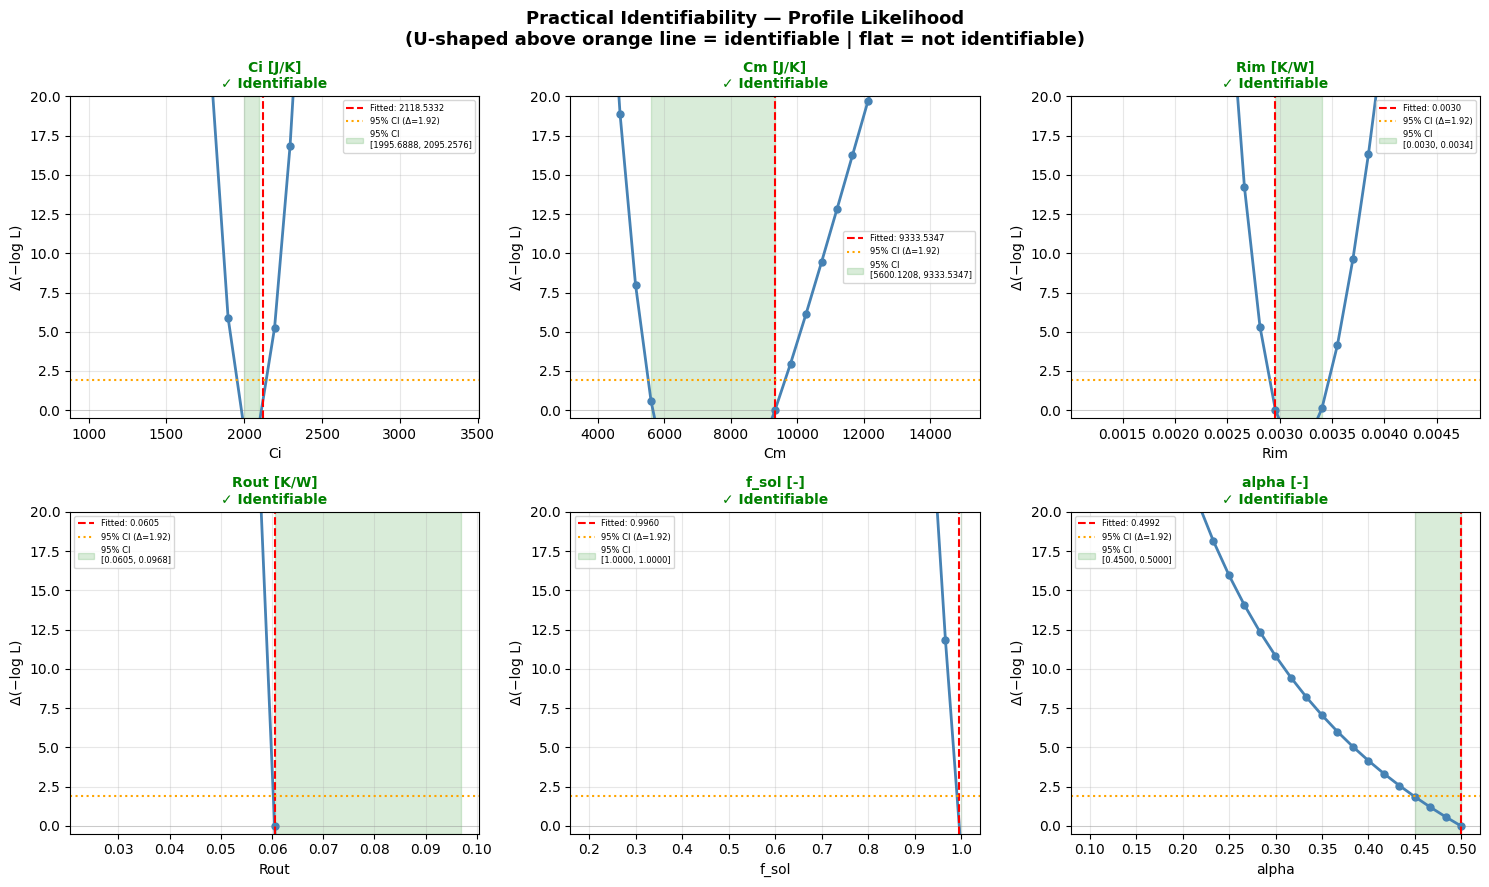

In [19]:
# ============================================================
# PRACTICAL IDENTIFIABILITY — PROFILE LIKELIHOOD (FIXED)
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import lmfit

# ----------------------------------------------------------
# HELPER — rebuild params from scratch (avoids deepcopy bug)
# ----------------------------------------------------------
def compute_nll_at_param(param_name, param_val, fitted_model, fitted_params, X, y_vals):
    """
    Fix param_name=param_val, hold all others at fitted values.
    Uses the EXISTING model instance directly — no re-instantiation.
    """
    # Build fresh lmfit Parameters (avoids deepcopy issues)
    p = lmfit.Parameters()
    for name, par in fitted_params.items():
        p.add(name,
              value = par.value,
              vary  = False,           # all fixed for forward-run
              min   = par.min if np.isfinite(par.min) else -np.inf,
              max   = par.max if np.isfinite(par.max) else  np.inf)

    # Override the one parameter being profiled
    p[param_name].value = param_val

    try:
        result  = fitted_model.model(p, X)
        Ti_pred = np.asarray(result.var['Ti'])
        res     = y_vals - Ti_pred
        n       = len(res)
        sigma2  = np.var(res, ddof=1)
        if sigma2 <= 0 or not np.isfinite(sigma2):
            return np.nan
        return 0.5 * n * np.log(2 * np.pi * sigma2) + 0.5 * np.sum(res**2) / sigma2
    except Exception as e:
        print(f"    ⚠ Error at {param_name}={param_val:.4f}: {e}")
        return np.nan


# ----------------------------------------------------------
# SETUP
# ----------------------------------------------------------
# Use the existing trained model instance from darkgreyfit
fitted_model  = model          # the DarkGreyModel instance from df.iloc[0]
fitted_params = model.result.params

# Training data — adjust variable names to match your notebook
y_train_vals = y_train.values        # numpy array
X_train_dict = X_train               # DataFrame or dict — whatever your model.model() expects

# Compute best -log L at fitted params (baseline = 0)
best_nll = compute_nll_at_param(
    'Ci', fitted_params['Ci'].value,   # dummy call with fitted value = baseline
    fitted_model, fitted_params, X_train_dict, y_train_vals
)
print(f"Baseline -log L at fitted params: {best_nll:.4f}")

# ----------------------------------------------------------
# PARAMETERS TO PROFILE
# ----------------------------------------------------------
# (param_name, display_label, n_grid_points, fraction_of_range_to_explore)
profile_params = [
    ('Ci',    'Ci [J/K]',   25, 0.60),
    ('Cm',    'Cm [J/K]',   25, 0.60),
    ('Rim',   'Rim [K/W]',  25, 0.60),
    ('Rout',  'Rout [K/W]', 25, 0.60),
    ('f_sol', 'f_sol [-]',  25, 0.80),
    ('alpha', 'alpha [-]',  25, 0.80),
]

# ----------------------------------------------------------
# COMPUTE PROFILES
# ----------------------------------------------------------
profiles = {}

for param_name, label, n_pts, rel_range in profile_params:
    if param_name not in fitted_params:
        print(f"  Skipping {param_name} — not in fitted_params")
        continue

    fitted_val = fitted_params[param_name].value
    p_min      = fitted_params[param_name].min
    p_max      = fitted_params[param_name].max

    # Grid: ±rel_range around fitted value, clamped to bounds
    lo   = max(p_min if np.isfinite(p_min) else fitted_val*0.01,
               fitted_val * (1 - rel_range))
    hi   = min(p_max if np.isfinite(p_max) else fitted_val*100,
               fitted_val * (1 + rel_range))
    grid = np.linspace(lo, hi, n_pts)

    print(f"\nProfiling {param_name} (fitted={fitted_val:.4f})  range=[{lo:.4f}, {hi:.4f}]")

    nll_vals = []
    for val in grid:
        nll = compute_nll_at_param(
            param_name, val,
            fitted_model, fitted_params,
            X_train_dict, y_train_vals
        )
        nll_vals.append(nll)
        print(f"  {param_name}={val:.4f}  →  -logL={nll:.4f}  Δ={nll - best_nll:.4f}")

    profiles[param_name] = {
        'label':      label,
        'grid':       grid,
        'nll':        np.array(nll_vals),
        'fitted_val': fitted_val,
        'best_nll':   best_nll,
    }

# ----------------------------------------------------------
# PLOT
# ----------------------------------------------------------
n_plots  = len(profiles)
ncols    = 3
nrows    = int(np.ceil(n_plots / ncols))
chi2_thr = 1.92   # χ²(1, 0.95) / 2

fig, axes = plt.subplots(nrows, ncols, figsize=(15, 4.5 * nrows))
axes = axes.flatten()

for i, (param_name, data) in enumerate(profiles.items()):
    ax  = axes[i]
    raw = data['nll']
    delta = raw - data['best_nll']

    # Replace NaN with large value for plotting
    delta_plot = np.where(np.isfinite(delta), delta, np.nanmax(delta[np.isfinite(delta)] if np.any(np.isfinite(delta)) else [20]))

    ax.plot(data['grid'], delta_plot, 'o-', color='steelblue', lw=2, ms=5)
    ax.axvline(data['fitted_val'], color='red',    ls='--', lw=1.5,
               label=f"Fitted: {data['fitted_val']:.4f}")
    ax.axhline(chi2_thr, color='orange', ls=':', lw=1.5,
               label=f'95% CI (Δ={chi2_thr})')
    ax.axhline(0, color='gray', ls='-', lw=0.5, alpha=0.4)

    # Shade 95% CI region
    ci_mask = delta_plot <= chi2_thr
    if ci_mask.any():
        ci_lo = data['grid'][ci_mask].min()
        ci_hi = data['grid'][ci_mask].max()
        ax.axvspan(ci_lo, ci_hi, alpha=0.15, color='green',
                   label=f'95% CI\n[{ci_lo:.4f}, {ci_hi:.4f}]')

    # Verdict
    max_delta = np.nanmax(delta_plot)
    if max_delta > chi2_thr and np.nanmin(delta_plot) < 0.5:
        verdict, col = '✓ Identifiable', 'green'
    elif max_delta < chi2_thr:
        verdict, col = '✗ Not identifiable (flat)', 'red'
    else:
        verdict, col = '⚠ Weakly identifiable', 'orange'

    ax.set_title(f'{data["label"]}\n{verdict}', color=col, fontweight='bold', fontsize=10)
    ax.set_xlabel(param_name); ax.set_ylabel('Δ(−log L)')
    ax.legend(fontsize=6); ax.grid(alpha=0.3)
    ax.set_ylim(-0.5, min(max_delta * 1.1 + 1, 20))

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Practical Identifiability — Profile Likelihood\n'
             '(U-shaped above orange line = identifiable | flat = not identifiable)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


  [Ci,Rim] 225/225  
  ✓ Done Ci vs Rim


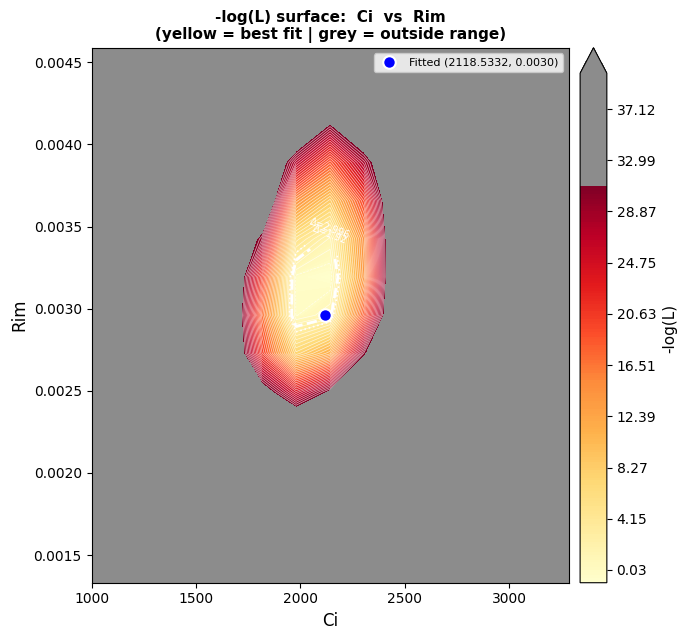

  Saved: identifiability_2D_Ci_Rim.png


In [ ]:
# ============================================================
# 2D JOINT LIKELIHOOD SURFACE — LECTURE STYLE (FAST VERSION)
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.cm as mcm
import lmfit
from concurrent.futures import ThreadPoolExecutor, as_completed

# ── Helper ────────────────────────────────────────────────
def compute_nll_at_param(param_name_val_dict, fitted_model,
                          fitted_params, X, y_vals):
    p = lmfit.Parameters()
    for name, par in fitted_params.items():
        p.add(name, value=par.value, vary=False,
              min=par.min if np.isfinite(par.min) else -np.inf,
              max=par.max if np.isfinite(par.max) else  np.inf)
    for name, val in param_name_val_dict.items():
        p[name].value = val
    try:
        result  = fitted_model.model(p, X)
        Ti_pred = np.asarray(result.var['Ti'])
        res     = y_vals - Ti_pred
        n       = len(res)
        sigma2  = np.var(res, ddof=1)
        if sigma2 <= 0 or not np.isfinite(sigma2):
            return np.nan
        return 0.5*n*np.log(2*np.pi*sigma2) + 0.5*np.sum(res**2)/sigma2
    except Exception:
        return np.nan

# ── Colormap (lecture style) ──────────────────────────────
def make_lecture_cmap():
    warm   = mcm.get_cmap('YlOrRd', 256)
    colors = warm(np.linspace(0, 1, 200))
    grey   = np.array([[0.55, 0.55, 0.55, 1.0]] * 56)
    return mcolors.LinearSegmentedColormap.from_list(
        'lecture_cmap', np.vstack([colors, grey])
    )

CMAP = make_lecture_cmap()

# ── Fast 2D plot ───────────────────────────────────────────
def plot_2d_likelihood_fast(px, py,
                             fitted_model, fitted_params, X, y_vals,
                             nx=15, ny=15,           # ← smaller = faster
                             x_range_factor=0.6,
                             y_range_factor=0.6,
                             clip_delta=40,
                             n_contour_lines=40,
                             n_workers=6):           # ← parallel threads
    fvx = fitted_params[px].value
    fvy = fitted_params[py].value

    def make_grid(pname, fv, factor, n):
        pmin = fitted_params[pname].min
        pmax = fitted_params[pname].max
        lo   = max(pmin if np.isfinite(pmin) else fv*0.01, fv*(1-factor))
        hi   = min(pmax if np.isfinite(pmax) else fv*100,  fv*(1+factor))
        return np.linspace(lo, hi, n)

    x_grid = make_grid(px, fvx, x_range_factor, nx)
    y_grid = make_grid(py, fvy, y_range_factor, ny)

    # ── Build all (i,j,xv,yv) jobs ───────────────────────
    jobs = [
        (i, j, xv, yv)
        for i, yv in enumerate(y_grid)
        for j, xv in enumerate(x_grid)
    ]
    total = len(jobs)
    Z = np.full((ny, nx), np.nan)

    # ── Worker function ───────────────────────────────────
    def _worker(args):
        i, j, xv, yv = args
        nll = compute_nll_at_param(
            {px: xv, py: yv},
            fitted_model, fitted_params, X, y_vals
        )
        return i, j, nll

    # ── Run in parallel ───────────────────────────────────
    done = 0
    with ThreadPoolExecutor(max_workers=n_workers) as executor:
        futures = {executor.submit(_worker, job): job for job in jobs}
        for future in as_completed(futures):
            i, j, nll = future.result()
            Z[i, j]   = nll
            done      += 1
            if done % 10 == 0 or done == total:
                print(f"  [{px},{py}] {done}/{total}  ", end='\r')

    print(f"\n  ✓ Done {px} vs {py}")

    # ── Normalize ─────────────────────────────────────────
    best_nll = compute_nll_at_param({}, fitted_model, fitted_params, X, y_vals)
    Z_delta  = Z - best_nll
    Z_plot   = np.clip(Z_delta, -1, clip_delta)

    # ── Plot ──────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(7, 6.5))
    ax.set_facecolor('#8c8c8c')

    cf = ax.contourf(x_grid, y_grid, Z_plot,
                     levels=np.linspace(-1, clip_delta, 200),
                     cmap=CMAP, extend='max')
    cb = plt.colorbar(cf, ax=ax, pad=0.02)
    cb.set_label('-log(L)', fontsize=11)

    ax.contour(x_grid, y_grid, Z_plot,
               levels=np.linspace(-1, clip_delta*0.75, n_contour_lines),
               colors='white', linewidths=0.5, alpha=0.7)

    for ci_level, ci_lw, ci_ls in [
        (1.92,  2.0, '--'),
        (2.996, 1.2, ':'),
    ]:
        try:
            cs = ax.contour(x_grid, y_grid, Z_delta,
                            levels=[ci_level],
                            colors='white', linewidths=ci_lw, linestyles=ci_ls)
            ax.clabel(cs, fmt=f'Δ={ci_level}', fontsize=7,
                      inline=True, colors='white')
        except Exception:
            pass

    ax.plot(fvx, fvy, 'o', color='blue', ms=9, zorder=10,
            markeredgecolor='white', markeredgewidth=1.5,
            label=f'Fitted ({fvx:.4f}, {fvy:.4f})')

    ax.set_xlabel(px, fontsize=12); ax.set_ylabel(py, fontsize=12)
    ax.set_title(f'-log(L) surface:  {px}  vs  {py}\n'
                 f'(yellow = best fit | grey = outside range)',
                 fontsize=11, fontweight='bold')
    ax.legend(fontsize=8, framealpha=0.8, facecolor='white')
    plt.tight_layout()
    fname = f'identifiability_2D_{px}_{py}.png'
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"  Saved: {fname}")

# ============================================================
# RUN
# ============================================================
fitted_model  = model
fitted_params = model.result.params
y_train_vals  = y_train.values

pairs = [
    ('Ci',  'Rim',  0.55, 0.55),
    ('Ci',  'Cm',   0.55, 0.55),
    ('Rim', 'Rout', 0.55, 0.55),
]

for (px, py, xr, yr) in pairs:
    plot_2d_likelihood_fast(
        px=px, py=py,
        fitted_model=fitted_model,
        fitted_params=fitted_params,
        X=X_train,
        y_vals=y_train_vals,
        nx=15, ny=15,          # 225 points vs 400 before → ~2× faster
        x_range_factor=xr,
        y_range_factor=yr,
        clip_delta=40,
        n_contour_lines=40,
        n_workers=6            # adjust to your CPU core count
    )


## Plot the different heat gains

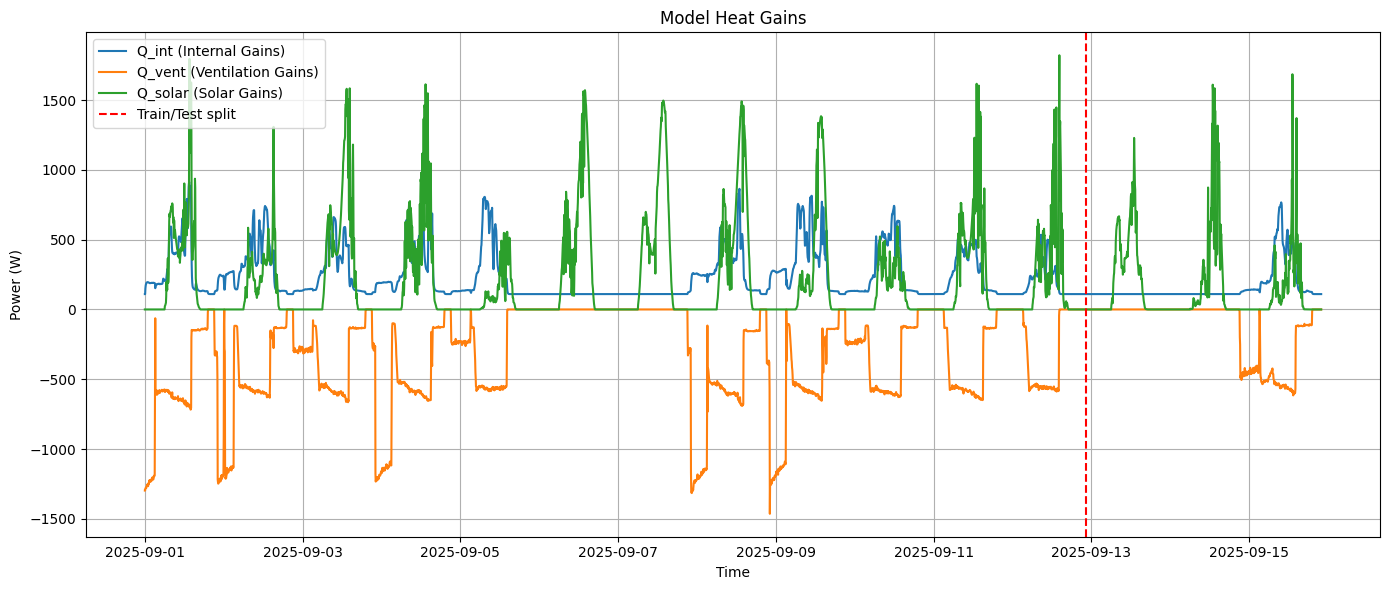

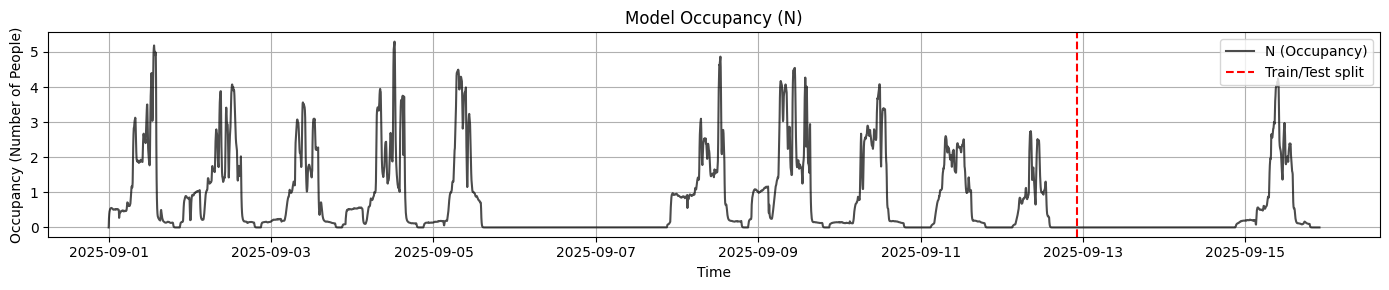

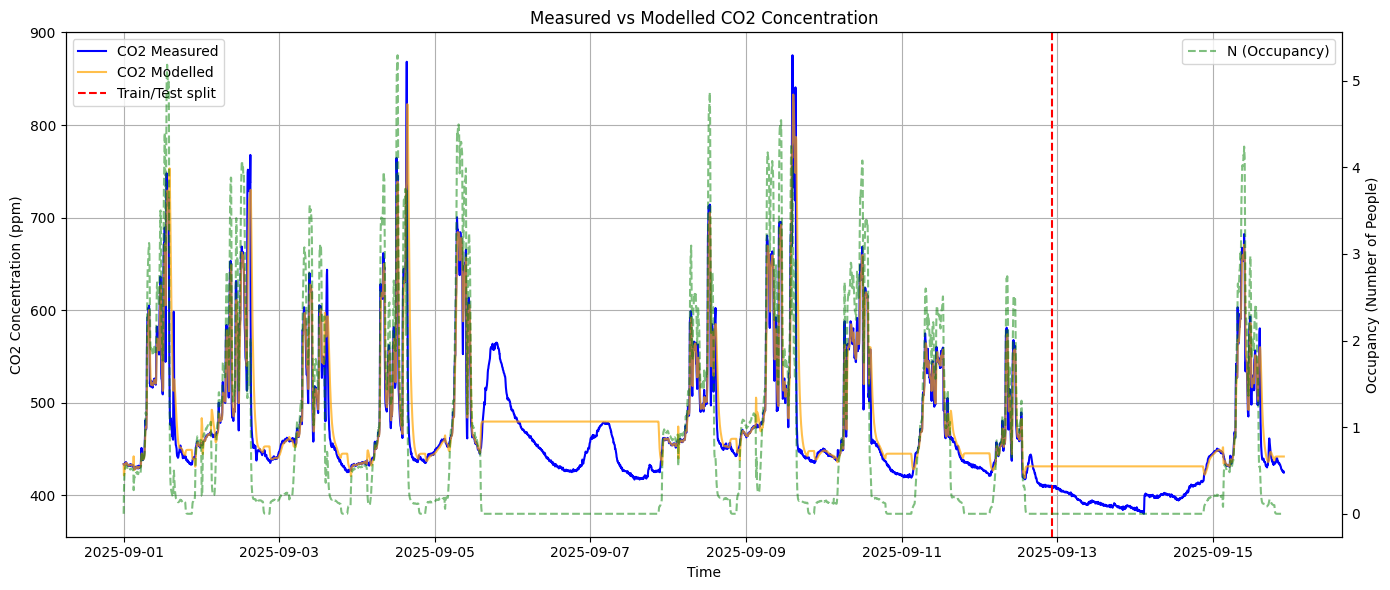

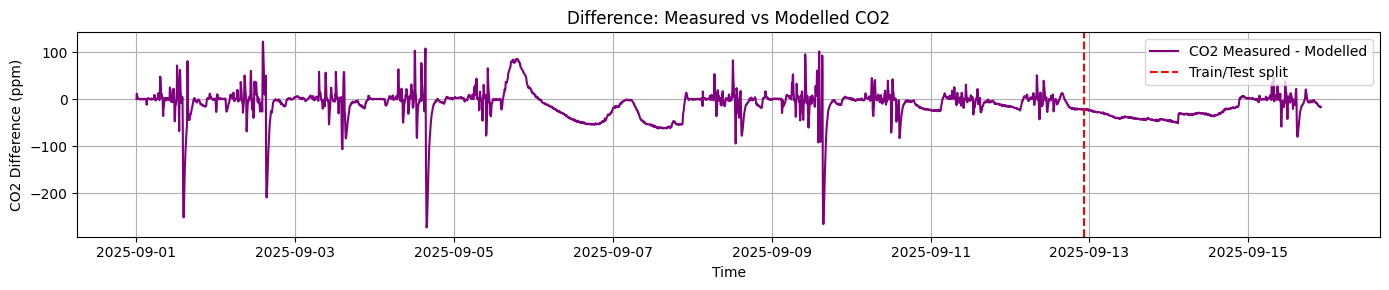

In [12]:
# Helper function to safely extract variables from results
def get_var(result, key, default=0):
    return result.var[key] if key in result.var else np.zeros(len(result.var[list(result.var.keys())[0]]))

# Extract Q_int, Q_vent, Q_solar, and N from train and test results
Q_int_train = get_var(train_results, 'Q_int')
Q_vent_train = get_var(train_results, 'Q_vent')
Q_solar_train = get_var(train_results, 'Q_solar')
N_train = get_var(train_results, 'N')

Q_int_test = get_var(test_results, 'Q_int')
Q_vent_test = get_var(test_results, 'Q_vent')
Q_solar_test = get_var(test_results, 'Q_solar')
N_test = get_var(test_results, 'N')

# Concatenate train and test for full time series
Q_int_full = np.concatenate([Q_int_train, Q_int_test])
Q_vent_full = np.concatenate([Q_vent_train, Q_vent_test])
Q_solar_full = np.concatenate([Q_solar_train, Q_solar_test])
N_full = np.concatenate([N_train, N_test])

# Get full index from y_train and y_test
full_index = pd.Index(list(y_train.index) + list(y_test.index))

# Plot heat gains
fig1, ax1 = plt.subplots(figsize=(14, 6))
ax1.plot(full_index, Q_int_full, label='Q_int (Internal Gains)')
ax1.plot(full_index, Q_vent_full, label='Q_vent (Ventilation Gains)')
ax1.plot(full_index, Q_solar_full, label='Q_solar (Solar Gains)')
ax1.axvline(x=y_train.index[-1], color='r', linestyle='--', label='Train/Test split')
ax1.set_xlabel('Time')
ax1.set_ylabel('Power (W)')
ax1.set_title('Model Heat Gains')
ax1.legend(loc='upper left')
ax1.grid(True)
plt.tight_layout()
plt.show()

# Plot N (occupancy) separately
fig2, ax2 = plt.subplots(figsize=(14, 3))
ax2.plot(full_index, N_full, color='black', label='N (Occupancy)', linewidth=1.5, alpha=0.7)
ax2.axvline(x=y_train.index[-1], color='r', linestyle='--', label='Train/Test split')
ax2.set_xlabel('Time')
ax2.set_ylabel('Occupancy (Number of People)')
ax2.set_title('Model Occupancy (N)')
ax2.legend(loc='upper right')
ax2.grid(True)
plt.tight_layout()
plt.show()


# Plot the difference between measured CO2 (c) and modelled CO2, along with N
# Extract measured and modelled CO2 concentrations
c_measured = pd.concat([input_df.loc[y_train.index, 'c'], input_df.loc[y_test.index, 'c']])
c_modelled = np.concatenate([get_var(train_results, 'c'), get_var(test_results, 'c')])

# Plot measured vs modelled CO2 and N
fig3, ax3 = plt.subplots(figsize=(14, 6))
ax3.plot(full_index, c_measured, label='CO2 Measured', color='blue')
ax3.plot(full_index, c_modelled, label='CO2 Modelled', color='orange', alpha=0.7)
ax3.axvline(x=y_train.index[-1], color='r', linestyle='--', label='Train/Test split')
ax3.set_xlabel('Time')
ax3.set_ylabel('CO2 Concentration (ppm)')
ax3.set_title('Measured vs Modelled CO2 Concentration')
ax3.legend(loc='upper left')
ax3.grid(True)

# Add a secondary axis for N
ax4 = ax3.twinx()
ax4.plot(full_index, N_full, label='N (Occupancy)', color='green', linestyle='--', alpha=0.5)
ax4.set_ylabel('Occupancy (Number of People)')
ax4.legend(loc='upper right')

plt.tight_layout()
plt.show()

# Plot the difference between measured and modelled CO2
fig4, ax5 = plt.subplots(figsize=(14, 3))
co2_diff = c_measured.values - c_modelled
ax5.plot(full_index, co2_diff, label='CO2 Measured - Modelled', color='purple')
ax5.axvline(x=y_train.index[-1], color='r', linestyle='--', label='Train/Test split')
ax5.set_xlabel('Time')
ax5.set_ylabel('CO2 Difference (ppm)')
ax5.set_title('Difference: Measured vs Modelled CO2')
ax5.legend(loc='upper right')
ax5.grid(True)
plt.tight_layout()
plt.show()